In [8]:
import warnings
warnings.filterwarnings("ignore")
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import json
from pathlib import Path
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

TensorFlow version: 2.13.0
GPU available: []


In [9]:
import os
import warnings
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

CONFIG = {
    "data_dir": "D:/PROJECTS/Crop-Disease-Detection/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)",
    "train_dir": "D:/PROJECTS/Crop-Disease-Detection/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train",
    "valid_dir": "D:/PROJECTS/Crop-Disease-Detection/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid",
    "model_save_path": "D:/PROJECTS/Crop-Disease-Detection/model/crop_disease_model.keras",
    "class_names_path": "D:/PROJECTS/Crop-Disease-Detection/model/class_names.json",
    "img_size": (224, 224),
    "batch_size": 32,
    "phase1_epochs": 15,
    "phase2_epochs": 20,
    "num_classes": 14
}

# 14 selected high-impact classes
SELECTED_CLASSES = [
    "Tomato___Early_blight",
    "Tomato___Late_blight",
    "Tomato___healthy",
    "Corn_(maize)___Common_rust_",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Corn_(maize)___healthy",
    "Apple___Apple_scab",
    "Apple___Black_rot",
    "Apple___healthy",
    "Potato___Early_blight",
    "Potato___Late_blight",
    "Potato___healthy",
    "Grape___Black_rot",
    "Grape___healthy"
]

os.makedirs("D:/PROJECTS/Crop-Disease-Detection/model", exist_ok=True)

# Verify paths
print("Train path exists:", os.path.exists(CONFIG["train_dir"]))
print("Valid path exists:", os.path.exists(CONFIG["valid_dir"]))
print(f"Training on {len(SELECTED_CLASSES)} classes")
print("Config loaded successfully")

Train path exists: True
Valid path exists: True
Training on 14 classes
Config loaded successfully


In [10]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json

# Training augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=False,
    brightness_range=[0.7, 1.3],
    fill_mode="nearest"
)

# Validation — only rescale
valid_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    CONFIG["train_dir"],
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=True,
    classes=SELECTED_CLASSES  # Only load 14 classes
)

valid_generator = valid_datagen.flow_from_directory(
    CONFIG["valid_dir"],
    target_size=CONFIG["img_size"],
    batch_size=CONFIG["batch_size"],
    class_mode="categorical",
    shuffle=False,
    classes=SELECTED_CLASSES  # Only load 14 classes
)

# Save class names
class_names = list(train_generator.class_indices.keys())
with open(CONFIG["class_names_path"], "w") as f:
    json.dump(class_names, f, indent=2)

print(f"Total training images  : {train_generator.samples}")
print(f"Total validation images: {valid_generator.samples}")
print(f"Number of classes      : {len(class_names)}")
print(f"Classes: {class_names}")
print(f"Class names saved to   : {CONFIG['class_names_path']}")

Found 26664 images belonging to 14 classes.
Found 6667 images belonging to 14 classes.
Total training images  : 26664
Total validation images: 6667
Number of classes      : 14
Classes: ['Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___healthy', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Apple___Apple_scab', 'Apple___Black_rot', 'Apple___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Grape___Black_rot', 'Grape___healthy']
Class names saved to   : D:/PROJECTS/Crop-Disease-Detection/model/class_names.json


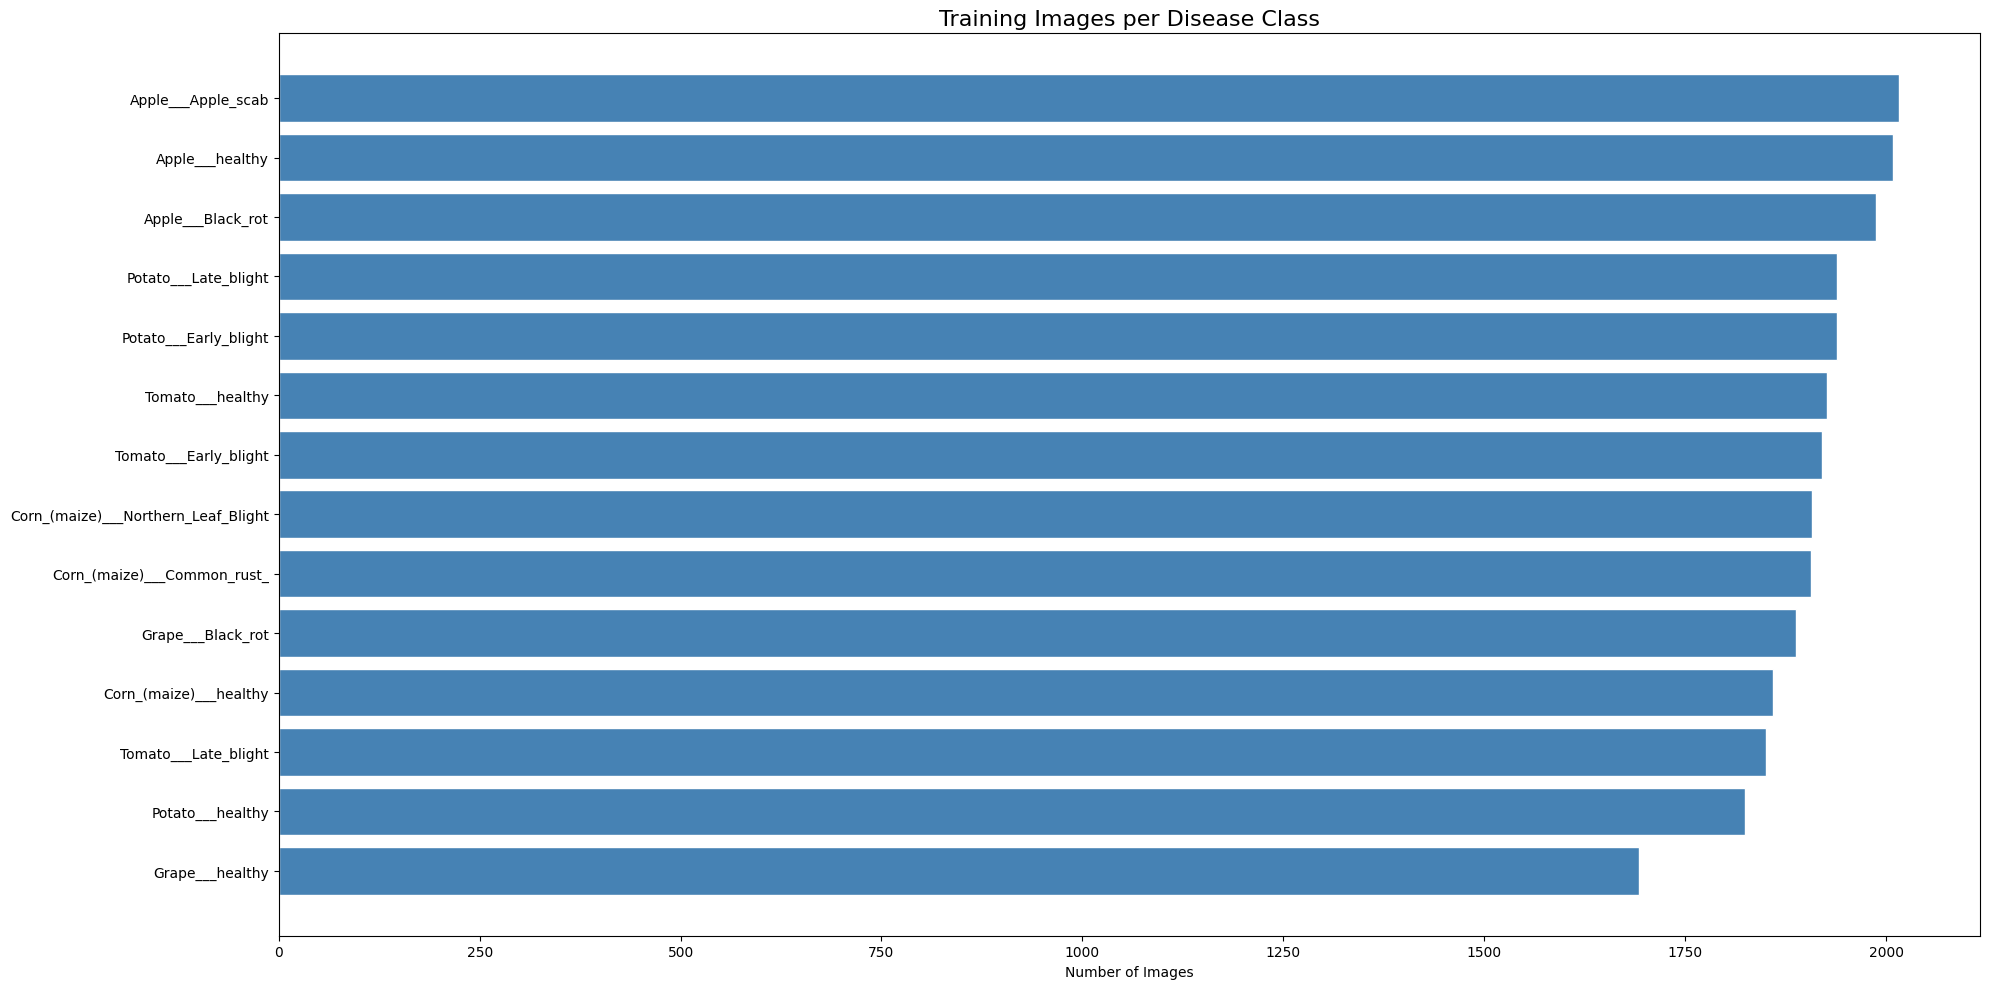


Min images in a class: 1692
Max images in a class: 2016
Average images per class: 1905


In [11]:
# Count images per class
class_counts = {}
for class_name in class_names:
    class_path = os.path.join(CONFIG["train_dir"], class_name)
    count = len(os.listdir(class_path))
    class_counts[class_name] = count

# Sort by count
sorted_classes = dict(
    sorted(class_counts.items(), key=lambda x: x[1])
)

plt.figure(figsize=(20, 10))
bars = plt.barh(
    list(sorted_classes.keys()),
    list(sorted_classes.values()),
    color="steelblue", edgecolor="white"
)
plt.title("Training Images per Disease Class", fontsize=16)
plt.xlabel("Number of Images")
plt.tight_layout()
plt.savefig("../assets/screenshots/class_distribution.png",
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\nMin images in a class: {min(class_counts.values())}")
print(f"Max images in a class: {max(class_counts.values())}")
print(f"Average images per class: {np.mean(list(class_counts.values())):.0f}")

In [12]:
import sys
sys.path.append("..")
from src.model import build_model, get_callbacks, compile_phase1

model, base_model = build_model(num_classes=len(class_names))
model = compile_phase1(model)
model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 efficientnetb0 (Functional  (None, 7, 7, 1280)        4049571   
 )                                                               
                                                                 
 global_average_pooling2d_1  (None, 1280)              0         
  (GlobalAveragePooling2D)                                       
                                                                 
 batch_normalization_1 (Bat  (None, 1280)              5120      
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 512)               655872    
                                                           